## Notebook to evaluate the effect of added Noise on standard and robust clustering-algorithms
### Goal of this notebook to compare standard and robust clustering algorithms on different forms and intensities of noise

In [4]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root))

#### Generating data


In [5]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000, centers=3, n_features=10, cluster_std=1.0, random_state=42)



#### Plot the original dataset

In [6]:
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA

df = X,y

pca = PCA(n_components=2)
components = pca.fit_transform(X)

fig = px.scatter(components, x=0, y=1, color=y)
fig.show()





#### Function to add noise
Die Funktion erzeugt Ausreißer, indem sie zusätzliche Rauschpunkte zum bestehenden Datensatz hinzufügt, anstatt vorhandene Datenpunkte zu verändern. Die Anzahl dieser Ausreißer wird prozentual zur ursprünglichen Datensatzgröße festgelegt. Bei einem Rauschanteil von 10 % werden beispielsweise zu 1000 ursprünglichen Datenpunkten 100 zusätzliche Ausreißer erzeugt.

Zur Generierung dieser Ausreißer wird zunächst der Wertebereich der vorhandenen Daten bestimmt. Anschließend werden neue Punkte zufällig so erzeugt, dass sie außerhalb dieses ursprünglichen Bereichs liegen. Dadurch wird sichergestellt, dass die neuen Punkte nicht innerhalb der bestehenden Cluster liegen und somit tatsächlich als Ausreißer wirken.

Das Ergebnis ist ein erweiterter Datensatz, der neben den ursprünglichen Clusterpunkten auch künstlich erzeugte Störpunkte enthält. Auf diese Weise kann untersucht werden, wie empfindlich Clustering-Verfahren auf zusätzliche Ausreißer reagieren.

In [7]:
import numpy as np
def add_outliers(X, y=None, noise_percent=10, min_distance_factor=2.5, random_state=42):
    """
    Add outlier points that are far away from the cluster center region.
    """
    rng = np.random.default_rng(random_state)

    n_samples, n_features = X.shape
    n_noise = int((noise_percent / 100) * n_samples)

    if n_noise == 0:
        return X.copy(), None if y is None else y.copy(), np.empty((0, n_features))

    center = X.mean(axis=0)
    dists = np.linalg.norm(X - center, axis=1)
    typical_radius = np.percentile(dists, 95)

    noise_points = []
    while len(noise_points) < n_noise:
        candidates = rng.normal(loc=center, scale=X.std(axis=0) * 3, size=(n_noise, n_features))
        candidate_dists = np.linalg.norm(candidates - center, axis=1)

        valid = candidates[candidate_dists > min_distance_factor * typical_radius]
        noise_points.extend(valid.tolist())

    X_noise = np.array(noise_points[:n_noise])
    X_new = np.vstack([X, X_noise])

    if y is not None:
        y_new = np.concatenate([y, np.full(n_noise, -1)])
    else:
        y_new = None

    return X_new, y_new, X_noise

#### Adding irrelevant features

In [8]:
def add_irrelevant_features(X, n_irrelevant=2, random_state=None):
    """
    Fügt irrelevante Merkmale zum Datensatz hinzu.

    Die neuen Features sind zufällig erzeugt und unabhängig
    von der eigentlichen Clusterstruktur.
    """
    rng = np.random.default_rng(random_state)

    n_samples = X.shape[0]

    # Skala der vorhandenen Daten grob übernehmen
    mean = np.mean(X, axis=0).mean()
    std = np.std(X, axis=0).mean()

    irrelevant = rng.normal(
        loc=mean,
        scale=std,
        size=(n_samples, n_irrelevant)
    )

    X_extended = np.hstack([X, irrelevant])
    return X_extended

#### Data preparation
##### Remove outlier

In [9]:
def remove_outliers_iqr(X, y=None, multiplier=1.5, min_features_outside=2):
    """
    Entfernt Ausreißer aus X anhand der IQR-Regel.

    Ein Datenpunkt wird entfernt, wenn er in mindestens
    `min_features_outside` Features außerhalb der IQR-Grenzen liegt.

    Returns
    -------
    X_clean : np.ndarray
        Datensatz ohne Ausreißer
    y_clean : np.ndarray oder None
        Zugehörige Labels ohne Ausreißer
    mask : np.ndarray
        Boolesche Maske der behaltenen Zeilen
    """
    Q1 = np.percentile(X, 25, axis=0)
    Q3 = np.percentile(X, 75, axis=0)
    IQR = Q3 - Q1

    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    # True, wenn ein Wert in einem Feature außerhalb der IQR-Grenzen liegt
    outside_bounds = (X < lower_bound) | (X > upper_bound)

    # Zähle pro Datenpunkt, in wie vielen Features er außerhalb liegt
    n_features_outside = np.sum(outside_bounds, axis=1)

    # Behalte nur Punkte, die in weniger als min_features_outside Features außerhalb liegen
    mask = n_features_outside < min_features_outside

    X_clean = X[mask]
    y_clean = y[mask] if y is not None else None

    return X_clean, y_clean, mask

##### Feature selection using laplace score

In [10]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform


def cal_lap_score(features, D, L):
    features_ = features - np.sum((features @ D) / np.sum(D))
    L_score = (features_ @ L @ features_) / (features_ @ D @ features_)
    return L_score


def get_k_nearest(dist, k, sample_index):
    # dist is zero means it is the sample itself
    return sorted(
        range(len(dist)),
        key=lambda i: dist[i] if i != sample_index else np.inf
    )[:k] + [sample_index]


def laplacian_score(df_arr, label=None, **kwargs):
    kwargs.setdefault("k_nearest", 5)
    
    '''
    Construct distance matrix, dist_matrix, using euclidean distance
    '''
    distances = pdist(df_arr, metric='euclidean')
    dist_matrix = squareform(distances)
    del distances
    '''
    Determine the edge of each sample pairs by k nearest neighbor
    '''
    edge_sparse_matrix = pd.DataFrame(
        np.zeros((df_arr.shape[0], df_arr.shape[0])),
        dtype=int
    )
    if label is None:
        for row_id, row in enumerate(dist_matrix):
            k_nearest_id = get_k_nearest(row, kwargs["k_nearest"], row_id)
            edge_sparse_matrix.iloc[k_nearest_id, k_nearest_id] = 1
    else:
        label = np.array(label)
        unique_label = np.unique(label)
        for i in unique_label:
            group_index = np.where(label == i)[0]
            edge_sparse_matrix.iloc[group_index, group_index] = 1
    S = dist_matrix * edge_sparse_matrix
    del dist_matrix, edge_sparse_matrix
    '''
    Calculate the Laplacian graph L
    '''
    D = np.diag(S.sum(axis=1))
    L = D - S
    del S
    '''
    Minimize the Laplacian score
    '''
    features_lap_score = np.apply_along_axis(
        func1d=lambda f: cal_lap_score(f, D, L), axis=0, arr=df_arr
    )
    return features_lap_score


In [11]:
import numpy as np
import plotly.express as px
from sklearn.decomposition import PCA

def plot_clusters(X, labels, title="Cluster Plot"):
    X = np.asarray(X)
    labels = np.asarray(labels)

    if X.shape[1] > 2:
        X_plot = PCA(n_components=2).fit_transform(X)
    else:
        X_plot = X

    fig = px.scatter(
        x=X_plot[:, 0],
        y=X_plot[:, 1],
        color=labels.astype(str),
        title=title,
        labels={"x": "PC1", "y": "PC2", "color": "Cluster"},
    )
    fig.show()

#### k-distance-plot for eps

Geschätzter eps-Wert: 4.632949574895305
Knickpunkt-Index: 998


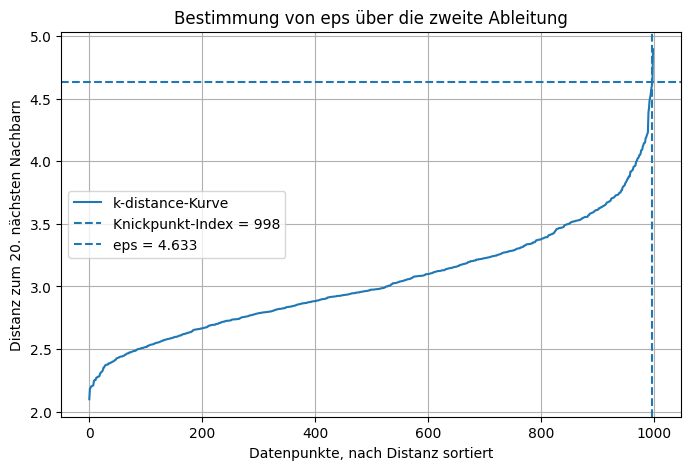

In [12]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# k-distance berechnen
neighbors = NearestNeighbors(n_neighbors=20)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Abstand zum k-ten Nachbarn
k_distances = np.sort(distances[:, -1])

# Erste und zweite Ableitung numerisch approximieren
first_derivative = np.gradient(k_distances)
second_derivative = np.gradient(first_derivative)

# Index des Maximums der zweiten Ableitung
knee_index = np.argmax(second_derivative)
eps_value = k_distances[knee_index]

print("Geschätzter eps-Wert:", eps_value)
print("Knickpunkt-Index:", knee_index)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_distances, label="k-distance-Kurve")
plt.axvline(knee_index, linestyle="--", label=f"Knickpunkt-Index = {knee_index}")
plt.axhline(eps_value, linestyle="--", label=f"eps = {eps_value:.3f}")
plt.xlabel("Datenpunkte, nach Distanz sortiert")
plt.ylabel(f"Distanz zum {20}. nächsten Nachbarn")
plt.title("Bestimmung von eps über die zweite Ableitung")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
import numpy as np
from sklearn.decomposition import PCA
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.colors import qualitative
from sklearn.metrics import silhouette_score, davies_bouldin_score

def plot_clustering_comparison(X, plot_labels, title="Vergleich der Clustering-Verfahren"):
    """
    plot_labels: Liste von Tupeln (subplot_title, labels)
    Beispiel:
        [
            ("Ground Truth", y),
            ("KMeans", kmeans),
            ("Hierarchisch", hcagg),
            ("DBSCAN", dbscan),
            ("RTKM", rtkm_labels),
        ]
    """
    X_arr = np.asarray(X)
    X_2d = PCA(n_components=2, random_state=42).fit_transform(X_arr)

    n_plots = len(plot_labels)
    n_cols = 3
    n_rows = int(np.ceil(n_plots / n_cols))

    subplot_titles = [name for name, _ in plot_labels]
    subplot_titles += [""] * (n_rows * n_cols - n_plots)

    fig = make_subplots(
        rows=n_rows,
        cols=n_cols,
        subplot_titles=subplot_titles,
        horizontal_spacing=0.07,
        vertical_spacing=0.10,
    )

    palette = qualitative.Plotly

    def color_for_label(label):
        if label == -1:
            return "black"
        return palette[int(label) % len(palette)]

    for plot_idx, (name, labels) in enumerate(plot_labels):
        labels = np.asarray(labels)
        row = plot_idx // n_cols + 1
        col = plot_idx % n_cols + 1

        for cluster_id in np.unique(labels):
            mask = labels == cluster_id
            legend_name = "Noise/Outlier" if cluster_id == -1 else f"Cluster {cluster_id}"

            fig.add_trace(
                go.Scatter(
                    x=X_2d[mask, 0],
                    y=X_2d[mask, 1],
                    mode="markers",
                    name=legend_name,
                    legendgroup=str(cluster_id),
                    showlegend=(plot_idx == 0),
                    marker=dict(
                        size=6,
                        color=color_for_label(cluster_id),
                        opacity=0.75,
                    ),
                ),
                row=row,
                col=col,
            )

    for r in range(1, n_rows + 1):
        for c in range(1, n_cols + 1):
            plot_number = (r - 1) * n_cols + c
            if plot_number <= n_plots:
                fig.update_xaxes(title_text="PC1", row=r, col=c)
                fig.update_yaxes(title_text="PC2", row=r, col=c)
            else:
                fig.update_xaxes(visible=False, row=r, col=c)
                fig.update_yaxes(visible=False, row=r, col=c)

    fig.update_layout(
        height=420 * n_rows,
        width=1400,
        title=title,
        template="plotly_white",
    )

    fig.show()
    
    
def print_silhouette_scores(X, label_sets):
    """
    label_sets: Liste von Tupeln (name, labels)
    Beispiel:
        [("KMeans", kmeans), ("DBSCAN", dbscan), ("RTKM", labels)]
    """
    X = np.asarray(X)

    for name, labels in label_sets:
        labels = np.asarray(labels)

        # Noise-Punkte wie bei DBSCAN ausnehmen
        mask = labels != -1
        labels_valid = labels[mask]
        X_valid = X[mask]

        n_clusters = len(np.unique(labels_valid))
        if n_clusters < 2:
            print(f"{name}: Silhouette nicht definiert (weniger als 2 Cluster)")
            continue

        score = silhouette_score(X_valid, labels_valid)
        print(f"{name}: Silhouette Score = {score:.4f}")
        
def print_davies_bouldin_scores(X, label_sets):
    """
    label_sets: Liste von Tupeln (name, labels)
    Beispiel:
        [("KMeans", kmeans), ("DBSCAN", dbscan), ("RTKM", labels)]
    """
    X = np.asarray(X)

    for name, labels in label_sets:
        labels = np.asarray(labels)

        # Noise-Punkte wie bei DBSCAN ausnehmen
        mask = labels != -1
        labels_valid = labels[mask]
        X_valid = X[mask]

        n_clusters = len(np.unique(labels_valid))
        if n_clusters < 2:
            print(f"{name}: Davies-Bouldin nicht definiert (weniger als 2 Cluster)")
            continue

        score = davies_bouldin_score(X_valid, labels_valid)
        print(f"{name}: Davies-Bouldin Index = {score:.4f}")
        
def clustering_metrics_table(X, label_sets):
    """
    label_sets: Liste von Tupeln (name, labels)
    Beispiel:
        [("KMeans", kmeans), ("Hierarchisch", hcagg), ("DBSCAN", dbscan), ("RTKM", labels)]
    """
    X = np.asarray(X)
    rows = []

    for name, labels in label_sets:
        labels = np.asarray(labels)

        # Noise/Outlier (-1) fuer interne Metriken ausschliessen
        mask = labels != -1
        X_valid = X[mask]
        labels_valid = labels[mask]

        n_points = len(labels_valid)
        n_clusters = len(np.unique(labels_valid))

        if n_points == 0:
            rows.append({
                "Verfahren": name,
                "Punkte bewertet": 0,
                "Cluster": 0,
                "Silhouette": np.nan,
                "Davies-Bouldin": np.nan,
                "Hinweis": "keine gueltigen Punkte"
            })
            continue

        if n_clusters < 2:
            rows.append({
                "Verfahren": name,
                "Punkte bewertet": n_points,
                "Cluster": n_clusters,
                "Silhouette": np.nan,
                "Davies-Bouldin": np.nan,
                "Hinweis": "weniger als 2 Cluster"
            })
            continue

        sil = silhouette_score(X_valid, labels_valid)
        dbi = davies_bouldin_score(X_valid, labels_valid)

        rows.append({
            "Verfahren": name,
            "Punkte bewertet": n_points,
            "Cluster": n_clusters,
            "Silhouette": round(sil, 4),
            "Davies-Bouldin": round(dbi, 4),
            "Hinweis": ""
        })

    df_metrics = pd.DataFrame(rows)
    print(df_metrics.to_string(index=False))
    return df_metrics


## Szenario 1: Clustering Verfahren ohne Rauschen

### Initilisierung der Verfahren

In [14]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from libs.RTKM import RTKM

kmeans = KMeans(n_clusters=3, random_state=43, n_init=20, init="k-means++").fit_predict(X)
hcagg = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X)
dbscan = DBSCAN(eps=4.6,min_samples=20).fit_predict(X)
rtkm = RTKM(X.T)
rtkm.perform_clustering(k=3,num_members=1, percent_outliers=0.0)
labels, outliers = rtkm.return_clusters()

### Plot results and evaluation metrics

In [ ]:
label_sets = [
    ("KMeans", kmeans),
    ("Hierarchisch", hcagg),
    ("DBSCAN", dbscan),
    ("RTKM", labels),
]

plot_clustering_comparison(X,label_sets)
clustering_metrics_table(X, label_sets)




   Verfahren  Punkte bewertet  Cluster  Silhouette  Davies-Bouldin Hinweis
      KMeans             1000        3      0.7762          0.3234        
Hierarchisch             1000        3      0.7762          0.3234        
      DBSCAN             1000        3      0.7762          0.3234        
        RTKM             1000        4      0.6252          0.4301        


,Verfahren,Punkte bewertet,Cluster,Silhouette,Davies-Bouldin,Hinweis
0,KMeans,1000,3,0.7762,0.3234,
1,Hierarchisch,1000,3,0.7762,0.3234,
2,DBSCAN,1000,3,0.7762,0.3234,
3,RTKM,1000,4,0.6252,0.4301,


# Szenario 2: Clustering Verfahren mit Ausreissern

## Szenario 2.1: Clustering Verfahren mit 10,20,30 Prozent Rauschen

### Fuege 10% Ausreisser hinzu

In [30]:
X_noise10p, y_noise, noise_points = add_outliers(
    X,
    y,
    noise_percent=10,
    min_distance_factor=2.5,
    random_state=42
)

X_noise20p, y_noise, noise_points = add_outliers(
    X,
    y,
    noise_percent=20,
    min_distance_factor=2.5,
    random_state=42
)

X_noise30p, y_noise, noise_points = add_outliers(
    X,
    y,
    noise_percent=30,
    min_distance_factor=2.5,
    random_state=42
)

### Neu Initialisierung der Verfahren

In [31]:
kmeans10p = KMeans(n_clusters=3, random_state=43, n_init=20, init="k-means++").fit_predict(X_noise10p)
hcagg10p = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_noise10p)
dbscan10p = DBSCAN(eps=4.6,min_samples=20).fit_predict(X_noise10p)
rtkm = RTKM(X_noise10p.T)
rtkm.perform_clustering(k=3,num_members=1, percent_outliers=0.1)
rtkm10p, outliers = rtkm.return_clusters()

kmeans20p = KMeans(n_clusters=3, random_state=43, n_init=20, init="k-means++").fit_predict(X_noise20p)
hcagg20p = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_noise20p)
dbscan20p = DBSCAN(eps=4.6,min_samples=20).fit_predict(X_noise20p)
rtkm = RTKM(X_noise20p.T)
rtkm.perform_clustering(k=3,num_members=1, percent_outliers=0.2)
rtkm20p, outliers = rtkm.return_clusters()

kmeans30p = KMeans(n_clusters=3, random_state=43, n_init=20, init="k-means++").fit_predict(X_noise30p)
hcagg30p = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_noise30p)
dbscan30p = DBSCAN(eps=4.6,min_samples=20).fit_predict(X_noise30p)
rtkm = RTKM(X_noise30p.T)
rtkm.perform_clustering(k=3,num_members=1, percent_outliers=0.3)
rtkm30p, outliers = rtkm.return_clusters()

### Plot visualization and results with 10% outliers

In [32]:
#10 percent noise
print("-----10 PERCENT NOISE-----")
label_sets10p = [
    ("KMeans", kmeans10p),
    ("Hierarchisch", hcagg10p),
    ("DBSCAN", dbscan10p),
    ("RTKM", rtkm10p),
]

plot_clustering_comparison(X_noise10p,label_sets10p)
clustering_metrics_table(X_noise10p, label_sets10p)

#20 percent noise
print("-----20 PERCENT NOISE-----")
label_sets20p = [
    ("KMeans", kmeans20p),
    ("Hierarchisch", hcagg20p),
    ("DBSCAN", dbscan20p),
    ("RTKM", rtkm20p),
]

plot_clustering_comparison(X_noise20p,label_sets20p)
clustering_metrics_table(X_noise20p, label_sets20p)

#30 percent noise
print("-----30 PERCENT NOISE-----")
label_sets30p = [
    ("KMeans", kmeans30p),
    ("Hierarchisch", hcagg30p),
    ("DBSCAN", dbscan30p),
    ("RTKM", rtkm30p),
]

plot_clustering_comparison(X_noise30p,label_sets30p)
clustering_metrics_table(X_noise30p, label_sets30p)

-----10 PERCENT NOISE-----


   Verfahren  Punkte bewertet  Cluster  Silhouette  Davies-Bouldin Hinweis
      KMeans             1100        3      0.5733          0.7781        
Hierarchisch             1100        3      0.5457          0.8482        
      DBSCAN             1000        3      0.7762          0.3234        
        RTKM             1100        4      0.6630          4.3878        
-----20 PERCENT NOISE-----


   Verfahren  Punkte bewertet  Cluster  Silhouette  Davies-Bouldin Hinweis
      KMeans             1200        3      0.5029          1.3133        
Hierarchisch             1200        3      0.4969          1.4208        
      DBSCAN             1000        3      0.7762          0.3234        
        RTKM             1200        4      0.5439          4.0860        
-----30 PERCENT NOISE-----


   Verfahren  Punkte bewertet  Cluster  Silhouette  Davies-Bouldin Hinweis
      KMeans             1300        3      0.4445          1.3813        
Hierarchisch             1300        3      0.4329          1.5388        
      DBSCAN             1000        3      0.7762          0.3234        
        RTKM             1300        4      0.4193          3.9584        


,Verfahren,Punkte bewertet,Cluster,Silhouette,Davies-Bouldin,Hinweis
0,KMeans,1300,3,0.4445,1.3813,
1,Hierarchisch,1300,3,0.4329,1.5388,
2,DBSCAN,1000,3,0.7762,0.3234,
3,RTKM,1300,4,0.4193,3.9584,
